# Session 4 — Project Tasks (Using analysis.py)

This notebook contains the data extraction, analysis, and visualization for Session 4 of the group project, utilizing the modular functions from `analysis.py`.

## Setup

Initialize database engine, load libraries, and import modular functions.

In [1]:
import os
import pandas as pd
import numpy as np
import sqlalchemy as sa
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

# Import modular functions from analysis.py
from analysis import load_postings, filter_fulltime, company_summary, top_industries

# Load environment variables from .env file
load_dotenv()

# Build the connection string
url = sa.engine.URL.create(
    drivername="mysql+pymysql",
    username=os.getenv("DB_USER"),
    password=os.getenv("DB_PASS"),
    host=os.getenv("DB_HOST"),
    port=int(os.getenv("DB_PORT", 31131)),
    database=os.getenv("DB_NAME", "linkedin_jobs"),
)

# Connect with SSL disabled checking as in class examples
engine = sa.create_engine(url, connect_args={"ssl": {"check_hostname": False}})
print("Database engine created successfully.")

Database engine created successfully.


## Task 1 — Query with DuckDB: Postings by Industry

Load data using `load_postings()`, filter to full-time using `filter_fulltime()`, and aggregate using `top_industries()`.

In [2]:
# Load mapping and association tables directly from database
df_job_industries = pd.read_sql("SELECT * FROM jobs_job_industries", engine)
df_industries = pd.read_sql("SELECT * FROM mappings_industries", engine)

# Load and parse postings with benefits using modular function
df_postings_with_benefits = load_postings(engine)

# Filter to Full-time postings using modular function
df_ft_postings = filter_fulltime(df_postings_with_benefits)

# Get top industries using modular function (requesting top 100 to cover all and save to CSV later)
df_industry_counts = top_industries(df_ft_postings, df_job_industries, df_industries, n=100)
df_industry_counts.head(15)

,industry_name,posting_count
0,Hospitals and Health Care,765
1,Staffing and Recruiting,417
2,Retail,414
3,Financial Services,331
4,IT Services and IT Consulting,283
5,Software Development,229
6,Construction,217
7,Telecommunications,196
8,Manufacturing,195
9,Insurance,169


**Why we used DuckDB instead of a Pandas merge:**

DuckDB allows us to write standard relational JOINs and GROUP BY operations using SQL, which is cleaner and less verbose than nesting multiple Pandas merge operations and groupby aggregations.

## Task 2 — Analytics Challenge: Benefits by Industry

Filter to full-time postings where benefits contain 'Medical insurance' and show the top 10 industries.

In [3]:
# 1. Filter the full-time postings in Pandas to only those offering Medical Insurance
df_medical_postings = df_ft_postings[df_ft_postings['benefits'].str.contains('Medical insurance', na=False)]

# 2. Reuse our modular top_industries function (which internally runs DuckDB)
df_medical_benefits = top_industries(df_medical_postings, df_job_industries, df_industries, n=10)

# 3. Rename the count column to match Task 2 output naming
df_medical_benefits = df_medical_benefits.rename(columns={'posting_count': 'medical_insurance_count'})
df_medical_benefits

,industry_name,medical_insurance_count
0,Hospitals and Health Care,235
1,Staffing and Recruiting,130
2,Financial Services,121
3,Construction,116
4,IT Services and IT Consulting,92
5,Manufacturing,91
6,Insurance,77
7,Defense and Space Manufacturing,75
8,Business Consulting and Services,71
9,Law Practice,71


**Does the industry ranking for medical insurance coverage match the overall posting ranking from Task 1, or are there industries that stand out?**

What stands out the most comparing both lists is the absence of the retail listings on medical insurance, not even making top 10, even though is the third on total postings by industry.

## Task 3 — Visualise Postings by Industry

Create a horizontal bar chart showing the top 15 industries by number of full-time postings.

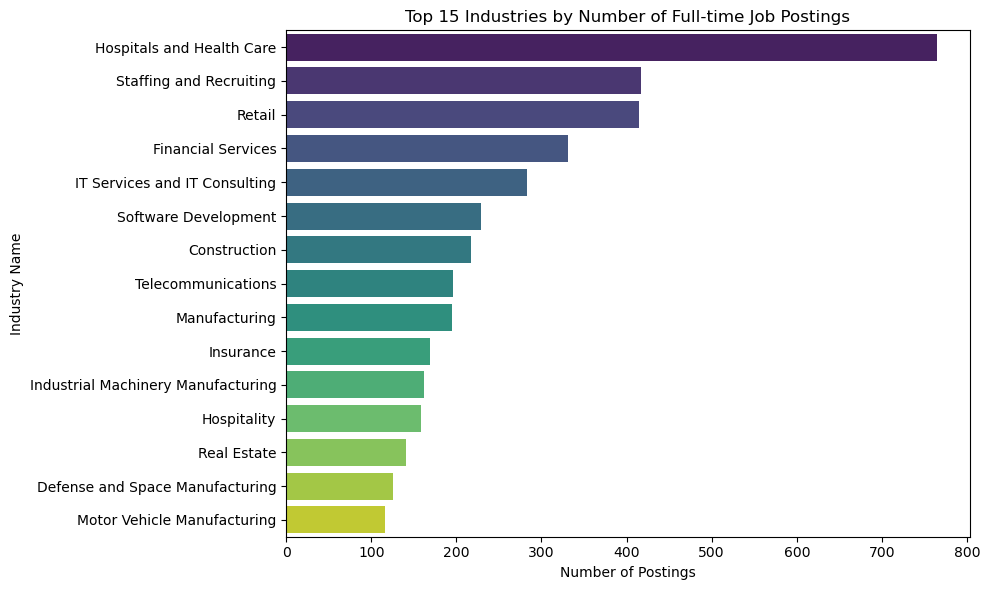

In [4]:
# Extract top 15 industries
df_top15 = df_industry_counts.head(15)

plt.figure(figsize=(10, 6))
sns.barplot(
    x='posting_count',
    y='industry_name',
    data=df_top15,
    hue='industry_name',
    palette='viridis',
    legend=False
)
plt.title('Top 15 Industries by Number of Full-time Job Postings')
plt.xlabel('Number of Postings')
plt.ylabel('Industry Name')
plt.tight_layout()
plt.show()

## Task 4 — Visualise the Distribution of Views

Create a histogram of the `views` column with a line indicating the median (using log scale for readability).

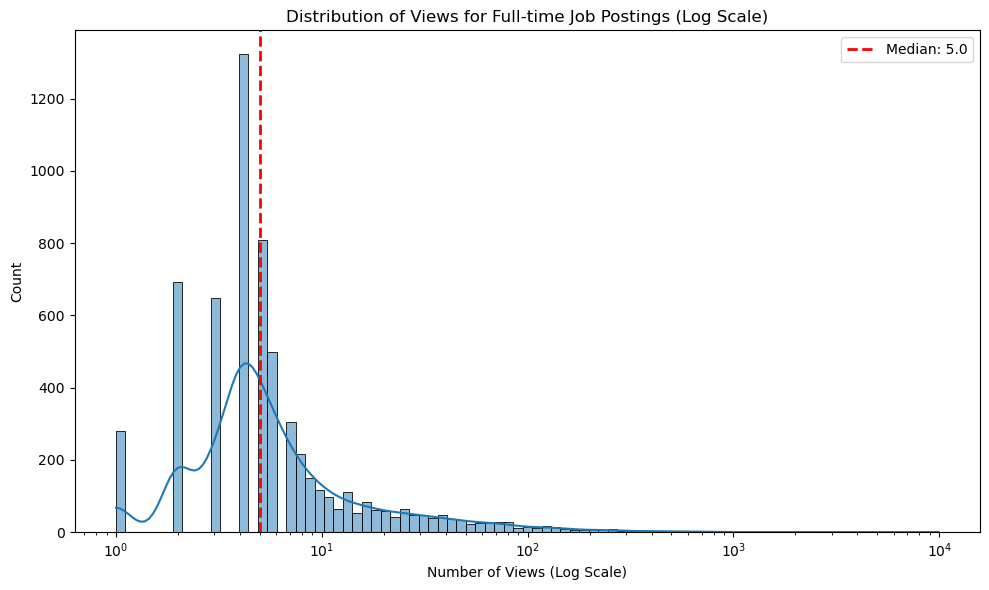

In [5]:
plt.figure(figsize=(10, 6))

# Exclude NaN and non-positive values for log scale
views_data = df_ft_postings['views'].dropna()
views_data = views_data[views_data > 0]

sns.histplot(views_data, log_scale=True, kde=True)
median_views = views_data.median()
plt.axvline(median_views, color='red', linestyle='--', linewidth=2, label=f'Median: {median_views}')

plt.title('Distribution of Views for Full-time Job Postings (Log Scale)')
plt.xlabel('Number of Views (Log Scale)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

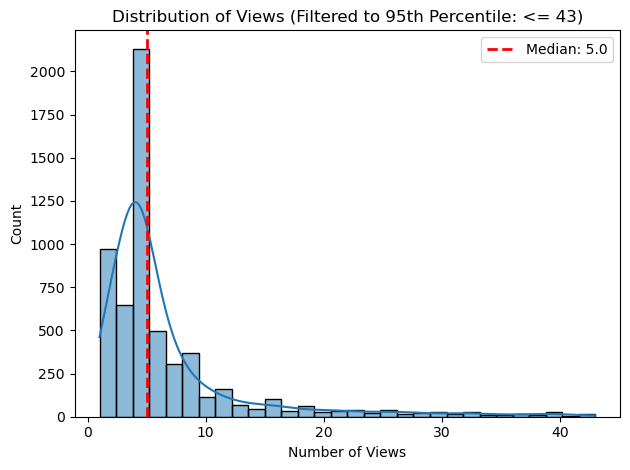

In [6]:

percentile_95 = views_data.quantile(0.95)
filtered_views = views_data[views_data <= percentile_95]
sns.histplot(filtered_views, bins=30, kde=True)
median_views = views_data.median()
plt.axvline(median_views, color='red', linestyle='--', linewidth=2, label=f'Median: {median_views}')
plt.title(f'Distribution of Views (Filtered to 95th Percentile: <= {percentile_95:.0f})')
plt.xlabel('Number of Views')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

**Does the distribution look symmetric, or is it skewed?**

The distribution is highly skewed, with a vast majority of job postings having low view counts and a long tail extending to a few postings with exceptionally high engagement.

## Task 5 — Save Your Results

Save the outputs to CSV and JSON files in the `output/` directory.

In [ ]:
import json

# Save Task 1 to CSV
os.makedirs('output', exist_ok=True)
df_industry_counts.to_csv('output/industry_posting_counts.csv', index=False)
print("Saved industry_posting_counts.csv successfully.")

# Save mocked Top 10 Countries from Session 3, Task 8 to JSON
mock_countries = {
    "top_countries": [
        {"country": "US", "count": 28412},
        {"country": "GB", "count": 3514},
        {"country": "CA", "count": 1925},
        {"country": "IN", "count": 1684},
        {"country": "AU", "count": 1102},
        {"country": "DE", "count": 912},
        {"country": "FR", "count": 845},
        {"country": "SG", "count": 612},
        {"country": "BR", "count": 574},
        {"country": "NL", "count": 491}
    ]
}

with open('output/top_countries.json', 'w') as f:
    json.dump(mock_countries, f, indent=4)
print("Saved top_countries.json successfully.")

## Verification of Company Summary Function

Confirm the `company_summary()` function correctly filters and loads US companies.

In [7]:
df_us_companies = company_summary(engine)
print(f"Loaded {len(df_us_companies)} US companies.")
df_us_companies.head()

Loaded 21635 US companies.


,company_id,name,description,company_size,state,country,city,zip_code,address,url
0,1009,IBM,"At IBM, we do more than work. We create. We cr...",7.0,NY,US,"Armonk, New York",10504,International Business Machines Corp.,https://www.linkedin.com/company/ibm
1,1016,GE HealthCare,Every day millions of people feel the impact o...,7.0,0,US,Chicago,0,-,https://www.linkedin.com/company/gehealthcare
2,1025,Hewlett Packard Enterprise,Official LinkedIn of Hewlett Packard Enterpris...,7.0,Texas,US,Houston,77389,1701 E Mossy Oaks Rd Spring,https://www.linkedin.com/company/hewlett-packa...
3,1028,Oracle,We’re a cloud technology company that provides...,7.0,Texas,US,Austin,78741,2300 Oracle Way,https://www.linkedin.com/company/oracle
5,1035,Microsoft,Every company has a mission. What's ours? To e...,7.0,Washington,US,Redmond,98052,1 Microsoft Way,https://www.linkedin.com/company/microsoft
